# Load **dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error,
                             accuracy_score,classification_report,confusion_matrix,
                             precision_score,recall_score,f1_score,roc_curve,roc_auc_score)

pd.set_option("display.max_columns",None)
%matplotlib inline



In [ ]:
df=pd.read_csv("/content/student_dataset_dirty.csv")

In [ ]:
df

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
0,1978,Bristi Khan,16,MALE,Mymensingh,Eight,77.0,2.6,83,62,68,213.0,PRIMARY,no,FAIL
1,3881,hasan akter,12,F,Dhaka,10th,88.5,3.8,45,56,92,193.0,Secondary,NO,fail
2,53,Sohan Talukder,14,Male,Khulna,7th,65.1,3.6,37,82,89,208.0,NaN,NO,fail
3,2552,Mitu Hossain,11,FEMALE,Rajshahi,Ten,82.8,4.2,83,96,59,238.0,illiterate,N,PASS
4,2247,Ayesha Ahmed,14,other,KHULNA,9th,94.2,1.4,81,36,48,165.0,primary,0,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,920,Rafi Hossain,15,NaN,Dacca,06,82.0,2.6,81,48,73,202.0,secondary,No,pass
9996,4308,Mim Akter,11,male,barisal,9,90.7,5.4,77,92,67,236.0,Graduate,no,Fail
9997,5700,Tamim Rahman,-18,O,Chittagong,Nine,87.6,1.5,53,72,61,186.0,illiterate,NaN,PASS
9998,538,Farhan Rahman,18,female,Chattogram,06,91.5,1.3,56,83,79,218.0,PRIMARY,yes,NaN


In [ ]:
df.shape

(10000, 15)

In [ ]:
df1 = df.copy()

## Data **Cleaning** and **Prepare**

In [ ]:
df1.head()

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
0,1978,Bristi Khan,16,MALE,Mymensingh,Eight,77.0,2.6,83,62,68,213.0,PRIMARY,no,FAIL
1,3881,hasan akter,12,F,Dhaka,10th,88.5,3.8,45,56,92,193.0,Secondary,NO,fail
2,53,Sohan Talukder,14,Male,Khulna,7th,65.1,3.6,37,82,89,208.0,NaN,NO,fail
3,2552,Mitu Hossain,11,FEMALE,Rajshahi,Ten,82.8,4.2,83,96,59,238.0,illiterate,N,PASS
4,2247,Ayesha Ahmed,14,other,KHULNA,9th,94.2,1.4,81,36,48,165.0,primary,0,pass


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Name                   9958 non-null   object 
 2   Age                    9804 non-null   object 
 3   Gender                 9162 non-null   object 
 4   City                   9775 non-null   object 
 5   Class                  10000 non-null  object 
 6   Attendance_Percentage  9745 non-null   float64
 7   Study_Hours_per_day    9803 non-null   float64
 8   Math_Score             9805 non-null   object 
 9   Science_Score          9800 non-null   object 
 10  English_Score          9804 non-null   object 
 11  Total_Score            9684 non-null   object 
 12  Parent_Education       8900 non-null   object 
 13  Internet_Access        8354 non-null   object 
 14  Result                 8906 non-null   object 
dtypes: 

In [ ]:
df1.isnull().sum()

,0
Student_ID,0
Name,42
Age,196
Gender,838
City,225
Class,0
Attendance_Percentage,255
Study_Hours_per_day,197
Math_Score,195
Science_Score,200


In [ ]:
df1.duplicated().sum()
df1=df1.drop_duplicates().reset_index(drop=True)


In [ ]:
df1.shape

(9850, 15)

In [ ]:
df1.dtypes

,0
Student_ID,object
Name,object
Age,object
Gender,object
City,object
Class,object
Attendance_Percentage,float64
Study_Hours_per_day,float64
Math_Score,object
Science_Score,object


In [ ]:
#Fixing categorical column :object to string
cat_cols=["Name","Gender","City","Class","Parent_Education","Internet_Access","Result"]
for col in cat_cols:
  df1[col]=df1[col].astype("string")

# Fixing numerical column types: object to numeric
num_cols=["Age","Math_Score","Science_Score","English_Score","Total_Score"]
for col in num_cols:
  df1[col]=pd.to_numeric(df1[col],errors="coerce")

df1['Student_ID']=df1['Student_ID'].astype("string")




In [ ]:
#standardize categorical text
cat_cols=["Name","Gender","City","Parent_Education","Internet_Access","Result"]
for col in cat_cols:
  df1[col]=df1[col].str.strip().str.title()


In [ ]:
#Fixing inconsistent categorical labels
#Student ID
df1["Student_ID"] = df1["Student_ID"].str.replace("STU-", "", regex=False)
df1["Student_ID"] = df1["Student_ID"].str.lstrip("0")
df1["Student_ID"]=pd.to_numeric(df1["Student_ID"],errors="coerce")
#Gender
df1["Gender"]=df1["Gender"].replace({
    "F":"Female",
    "M":"Male",
    "O":"Other"

})
#City
df1["City"]=df1["City"].replace({
    "Mymensign":"Mymensingh",
    "Dacca":"Dhaka",
    "Chattogram":"Chittagong",
    "Ctg":"Chittagong",

    "Barishal":"Barisal"
})
#Class
df1["Class"]=df1["Class"].replace({
    "10":"10th",
    "Ten":"10th",
    "Eight":"8th",
    "8":"8th",
    "Seven":"7th",
    "8":"8th",
    "06":"6th",
    "6":"6th",
    "Six":"6th",
    "Nine":"9th",
    "9":"9th",
    "7":"7th"

})
#Parent_Education
df1["Parent_Education"]=df1["Parent_Education"].replace({
    "Post Graduate":"Postgraduate"
})
#Internet_Access
df1["Internet_Access"]=df1["Internet_Access"].replace({
    "N":"No",
    "0":"No",
    "Y":"Yes",
    "1":"Yes"
})
#Result
df1["Result"]=df1["Result"].replace({
    "P":"Pass",
    "F":"Fail"


})



In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9850 entries, 0 to 9849
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9850 non-null   Int64  
 1   Name                   9809 non-null   string 
 2   Age                    9553 non-null   float64
 3   Gender                 9028 non-null   string 
 4   City                   9631 non-null   string 
 5   Class                  9850 non-null   string 
 6   Attendance_Percentage  9602 non-null   float64
 7   Study_Hours_per_day    9657 non-null   float64
 8   Math_Score             9608 non-null   float64
 9   Science_Score          9614 non-null   float64
 10  English_Score          9615 non-null   float64
 11  Total_Score            9457 non-null   float64
 12  Parent_Education       8773 non-null   string 
 13  Internet_Access        8230 non-null   string 
 14  Result                 8769 non-null   string 
dtypes: I

In [ ]:
#Handle Outliers
df1.loc[(df1["Age"] < 5) | (df1["Age"] > 25), "Age"] = np.nan
df1.loc[(df1["Attendance_Percentage"] < 0) | (df1["Attendance_Percentage"] > 100), "Attendance_Percentage"] = np.nan
df.loc[(df['Study_Hours_per_day'] < 0) | (df['Study_Hours_per_day'] > 16), 'Study_Hours_per_day'] = np.nan

for c in ["Math_Score","Science_Score","English_Score"]:
  df1.loc[(df1[c] < 0) | (df1[c] > 100), c] = np.nan

df1[num_cols].describe()

,Age,Math_Score,Science_Score,English_Score,Total_Score
count,9364.000000,9408.000000,9402.000000,9424.000000,9457.000000
mean,14.556813,64.766582,64.311636,64.260717,190.436079
std,2.288233,20.313676,20.144914,20.160837,49.422675
min,11.000000,30.000000,30.000000,30.000000,-13.000000
25%,13.000000,47.000000,47.000000,47.000000,160.000000
50%,15.000000,65.000000,64.000000,64.000000,190.000000
75%,17.000000,82.000000,82.000000,82.000000,218.000000
max,18.000000,99.000000,99.000000,99.000000,517.000000


In [ ]:
#Handle Missing values
#Categorical value - > Mode
for c in cat_cols:
  df1[c]=df1[c].fillna(df1[c].mode()[0])
#Numeric value - > Median
df1["Attendance_Percentage"]=df1["Attendance_Percentage"].fillna(df1["Attendance_Percentage"].median())
df1["Study_Hours_per_day"]=df1["Study_Hours_per_day"].fillna(df1["Study_Hours_per_day"].median())
for c in num_cols:
  df1[c]=df1[c].fillna(df1[c].median())


In [ ]:
# Recompute Total_Score
df1["Total_Score"] = df1["Math_Score"] + df1["English_Score"] + df1["Science_Score"]
df1[["Math_Score","English_Score","Science_Score","Total_Score"]].head()

,Math_Score,English_Score,Science_Score,Total_Score
0,83.0,68.0,62.0,213.0
1,45.0,92.0,56.0,193.0
2,37.0,89.0,82.0,208.0
3,83.0,59.0,96.0,238.0
4,81.0,48.0,36.0,165.0


In [ ]:
#from google.colab import files

#df1.to_csv("student_dataset_cleaned.csv", index=False)
#files.download("student_dataset_cleaned.csv")

# Part-B:Feature **Engeering**

In [ ]:
#creating new features( Average_Score, Study_Efficiency, Attendance_Category)
#(Average_Score)
df1["Average_Score"]= (df1["Math_Score"]+df1["Science_Score"]+df1["English_Score"])/3
df1["Average_Score"]=df1["Average_Score"].round(2)

#Study_Efficiency
df1["Study_Efficiency"]=(df1["Total_Score"]/df1["Study_Hours_per_day"].replace(0, np.nan))
df1["Study_Efficiency"]=df1["Study_Efficiency"].round(2)
df1["Study_Efficiency"]=df1["Study_Efficiency"].fillna(df1["Study_Efficiency"].median())

#Attendance_Category

conditions=[

            df1["Attendance_Percentage"] >= 90,
            df1["Attendance_Percentage"] >= 75,
            df1["Attendance_Percentage"] >= 60,
]
choices = ["Excellent","Good","Average"]
df1["Attendance_Category"]=np.select(conditions,choices,default="Poor")

In [ ]:
df1[["Total_Score","Study_Hours_per_day","Study_Efficiency"]].head(10)

,Total_Score,Study_Hours_per_day,Study_Efficiency
0,213.0,2.6,81.92
1,193.0,3.8,50.79
2,208.0,3.6,57.78
3,238.0,4.2,56.67
4,165.0,1.4,117.86
5,160.0,4.9,32.65
6,228.0,4.6,49.57
7,162.0,3.5,46.29
8,215.0,5.7,37.72
9,187.0,1.7,110.00


In [ ]:
#encode categorical variable
#one-hot-encoding
encode_cols = ["Gender","City","Class"]
df1_encoded =  pd.get_dummies(df1 ,  columns= encode_cols , drop_first=True)
df1_encoded.head()


,Student_ID,Name,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result,Average_Score,Study_Efficiency,Attendance_Category,Gender_Male,Gender_Other,City_Chittagong,City_Dhaka,City_Khulna,City_Mymensingh,City_Rajshahi,City_Rangpur,City_Sylhet,Class_6th,Class_7th,Class_8th,Class_9th
0,1978,Bristi Khan,16.0,77.0,2.6,83.0,62.0,68.0,213.0,Primary,No,Fail,71.00,81.92,Good,True,False,False,False,False,True,False,False,False,False,False,True,False
1,3881,Hasan Akter,12.0,88.5,3.8,45.0,56.0,92.0,193.0,Secondary,No,Fail,64.33,50.79,Good,False,False,False,True,False,False,False,False,False,False,False,False,False
2,53,Sohan Talukder,14.0,65.1,3.6,37.0,82.0,89.0,208.0,Primary,No,Fail,69.33,57.78,Average,True,False,False,False,True,False,False,False,False,False,True,False,False
3,2552,Mitu Hossain,11.0,82.8,4.2,83.0,96.0,59.0,238.0,Illiterate,No,Pass,79.33,56.67,Good,False,False,False,False,False,False,True,False,False,False,False,False,False
4,2247,Ayesha Ahmed,14.0,94.2,1.4,81.0,36.0,48.0,165.0,Primary,No,Pass,55.00,117.86,Excellent,False,True,False,False,True,False,False,False,False,False,False,False,True


In [ ]:
#Categorical Encoding
#Label Encoding
le=LabelEncoder()

df1_encoded["Parent_Education"]=le.fit_transform(df1_encoded["Parent_Education"])
df1_encoded["Attendance_Category"]=le.fit_transform(df1_encoded["Attendance_Category"])
df1_encoded["Internet_Access"]=le.fit_transform(df1_encoded["Internet_Access"])
df1_encoded["Result"]=le.fit_transform(df1_encoded["Result"])

df1_encoded.head()

,Student_ID,Name,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result,Average_Score,Study_Efficiency,Attendance_Category,Gender_Male,Gender_Other,City_Chittagong,City_Dhaka,City_Khulna,City_Mymensingh,City_Rajshahi,City_Rangpur,City_Sylhet,Class_6th,Class_7th,Class_8th,Class_9th
0,1978,Bristi Khan,16.0,77.0,2.6,83.0,62.0,68.0,213.0,4,0,0,71.00,81.92,2,True,False,False,False,False,True,False,False,False,False,False,True,False
1,3881,Hasan Akter,12.0,88.5,3.8,45.0,56.0,92.0,193.0,5,0,0,64.33,50.79,2,False,False,False,True,False,False,False,False,False,False,False,False,False
2,53,Sohan Talukder,14.0,65.1,3.6,37.0,82.0,89.0,208.0,4,0,0,69.33,57.78,0,True,False,False,False,True,False,False,False,False,False,True,False,False
3,2552,Mitu Hossain,11.0,82.8,4.2,83.0,96.0,59.0,238.0,2,0,1,79.33,56.67,2,False,False,False,False,False,False,True,False,False,False,False,False,False
4,2247,Ayesha Ahmed,14.0,94.2,1.4,81.0,36.0,48.0,165.0,4,0,1,55.00,117.86,1,False,True,False,False,True,False,False,False,False,False,False,False,True


In [ ]:
#corr = df1_encoded.corr(numeric_only=True)

#corr["Result"].sort_values(ascending=False)

# Part-**C**: Linear Regression

Target Class- Total score

In [ ]:
#Copy cleaned dataset for linear Regression and Logistic Regression because these two's target class different
df2_encoded = df1_encoded.copy()

In [ ]:
drop_for_linear = ["Student_ID","Name","Total_Score","Math_Score","Average_Score" ,"Study_Efficiency",

                   "English_Score","Science_Score","Result"]
X_lin = df1_encoded.drop(columns = drop_for_linear , errors = "ignore")
y_lin = df1_encoded["Total_Score"]

X_train , X_test , y_train , y_test = train_test_split(X_lin,y_lin ,test_size = 0.2 , random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

lin_model = LinearRegression()
lin_model.fit(X_train_scaled,y_train)
y_pred = lin_model.predict(X_test_Scaled)

print("R2:" , r2_score(y_test,y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))





R2: -0.005961879338169052
MAE: 27.968659084774195
RMSE: 34.75139997145087


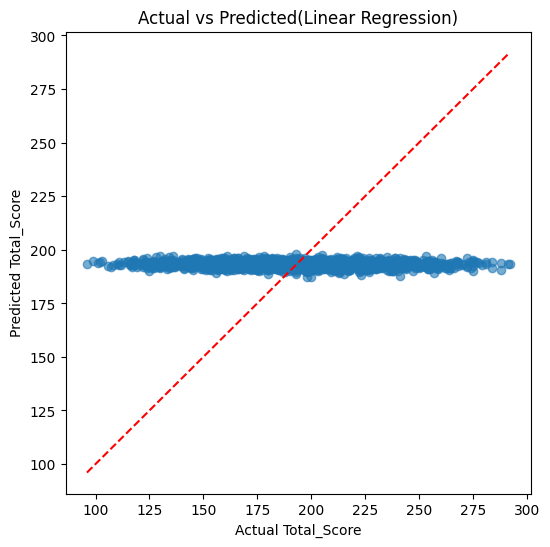

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],"r--")
plt.xlabel("Actual Total_Score")
plt.ylabel("Predicted Total_Score")
plt.title("Actual vs Predicted(Linear Regression)")
plt.show()

In [ ]:
# Coefficient interpretation
coef_df = pd.DataFrame({"Feature":X_lin.columns,"Coefficient":lin_model.coef_})
coef_df.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
7,Gender_Other,0.632208
0,Age,0.493914
6,Gender_Male,0.453632
18,Class_9th,0.343139
4,Internet_Access,0.322674
16,Class_7th,0.207923
17,Class_8th,0.192814
13,City_Rangpur,0.130855
15,Class_6th,0.092656
11,City_Mymensingh,-0.025091


# Part-D : Logistic **Regression**

Target: Result

In [ ]:
drop_for_log = ["Result","Student_ID","Name","Study_Efficiency","Average_Score"]
X_log = df2_encoded.drop(columns = drop_for_log , errors = "ignore")
y_log = df2_encoded["Result"]

X_train , X_test , y_train , y_test = train_test_split(X_log,y_log ,test_size = 0.2 , random_state = 42 , stratify=y_log)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train_scaled,y_train)
y_pred = log_model.predict(X_test_Scaled)
y_prob = log_model.predict_proba(X_test_Scaled)[:,1]

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))



Accuracy: 0.5593908629441624
Precision: 0.4117647058823529
Recall: 0.008092485549132947
F1 Score: 0.015873015873015872


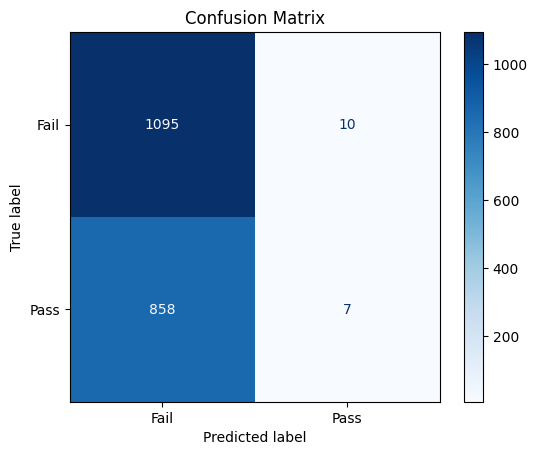

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

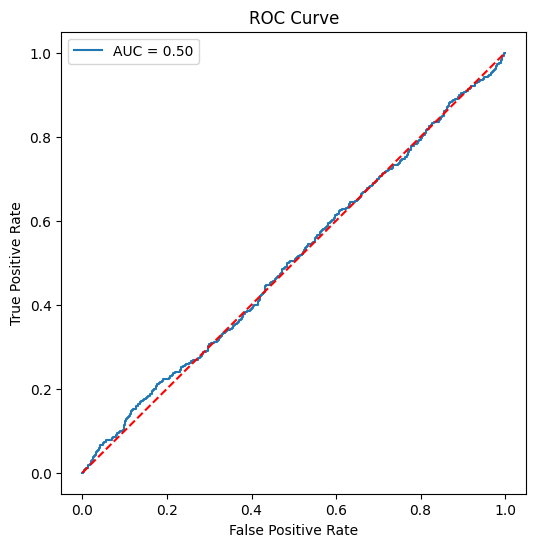

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# Class balance check
df2_encoded['Result'].value_counts(normalize=True)

,proportion
Result,
0,0.560812
1,0.439188
